#### House Price Prediction

In [1]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#import dataset
import pandas as pd
dataset=pd.read_excel("HousePricePrediction.xlsx")
print(dataset.head(5))

   Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0   0          60       RL     8450    Inside     1Fam            5   
1   1          20       RL     9600       FR2     1Fam            8   
2   2          60       RL    11250    Inside     1Fam            5   
3   3          70       RL     9550    Corner     1Fam            5   
4   4          60       RL    14260       FR2     1Fam            5   

   YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0       2003          2003     VinylSd         0.0        856.0   208500.0  
1       1976          1976     MetalSd         0.0       1262.0   181500.0  
2       2001          2002     VinylSd         0.0        920.0   223500.0  
3       1915          1970     Wd Sdng         0.0        756.0   140000.0  
4       2000          2000     VinylSd         0.0       1145.0   250000.0  


In [3]:
dataset.shape

(2919, 13)

#### Data Preprocessing

In [4]:
type(dataset)
import pandas as pd
dataset=pd.DataFrame(dataset)
dataset=pd.read_excel("HousePricePrediction.xlsx")
# categorical columns
object_cols = dataset.select_dtypes(include=['object']).columns
print("Categorical variables:", len(object_cols))

# integer columns
int_cols = dataset.select_dtypes(include=['int64']).columns
print("Integer variables:", len(int_cols))

Categorical variables: 4
Integer variables: 6


In [5]:
type(dataset)
import pandas as pd
dataset=pd.DataFrame(dataset)
dataset=pd.read_excel("HousePricePrediction.xlsx")
# categorical columns
object_cols = dataset.select_dtypes(include=['object']).columns
print("Categorical variables:", len(object_cols))

# float columns
float_cols = dataset.select_dtypes(include=['float64']).columns
print("Float variables:", len(float_cols))

Categorical variables: 4
Float variables: 3


#### Exploratory Data Analysis

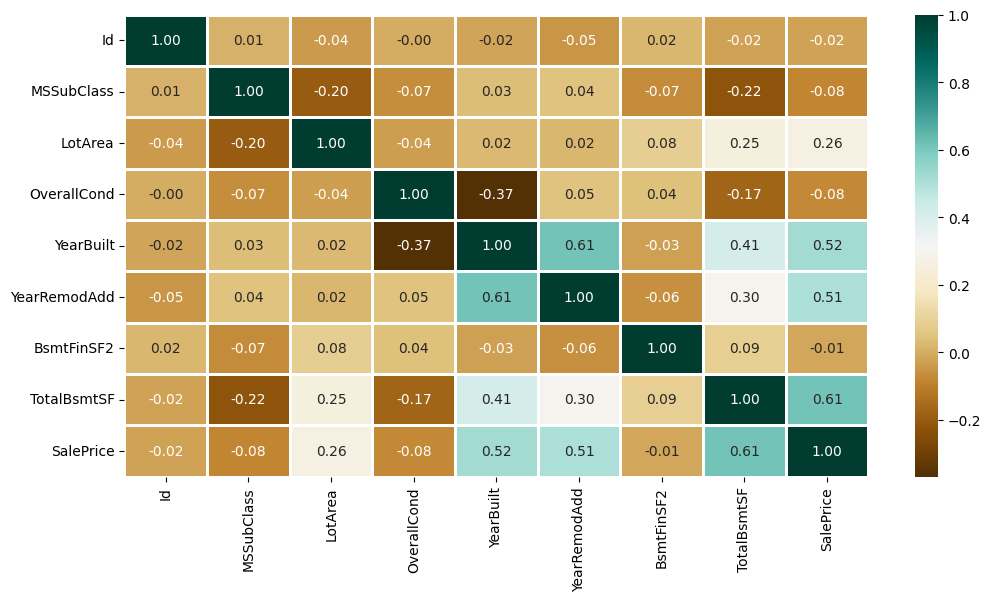

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
numerical_dataset = dataset.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(12, 6))
sns.heatmap(
    numerical_dataset.corr(),
    cmap='BrBG',
    fmt='.2f',
    linewidths=2,
    annot=True
)
plt.show()

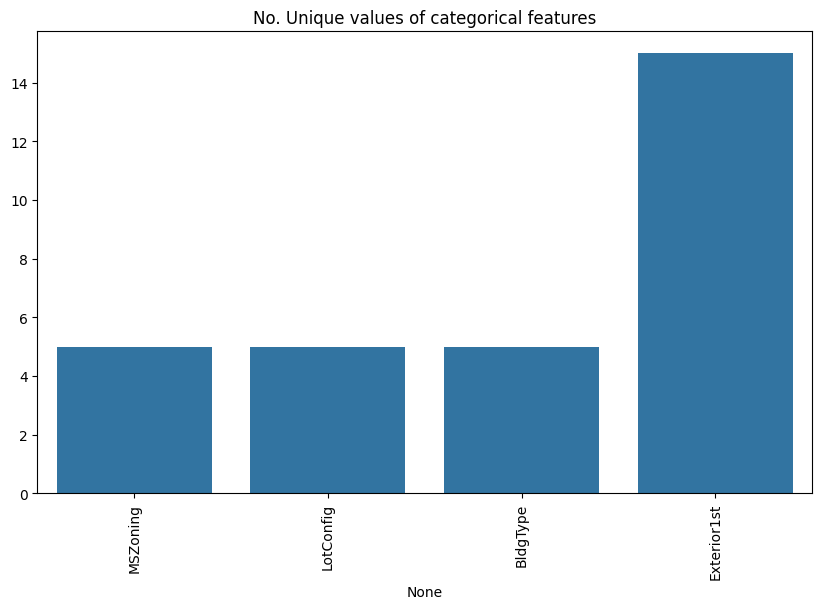

In [7]:
unique_values = []
for col in object_cols:
    unique_values.append(dataset[col].nunique())

plt.figure(figsize=(10,6))
plt.title("No. Unique values of categorical features")
plt.xticks(rotation=90)
sns.barplot(x=object_cols, y=unique_values)
plt.show()

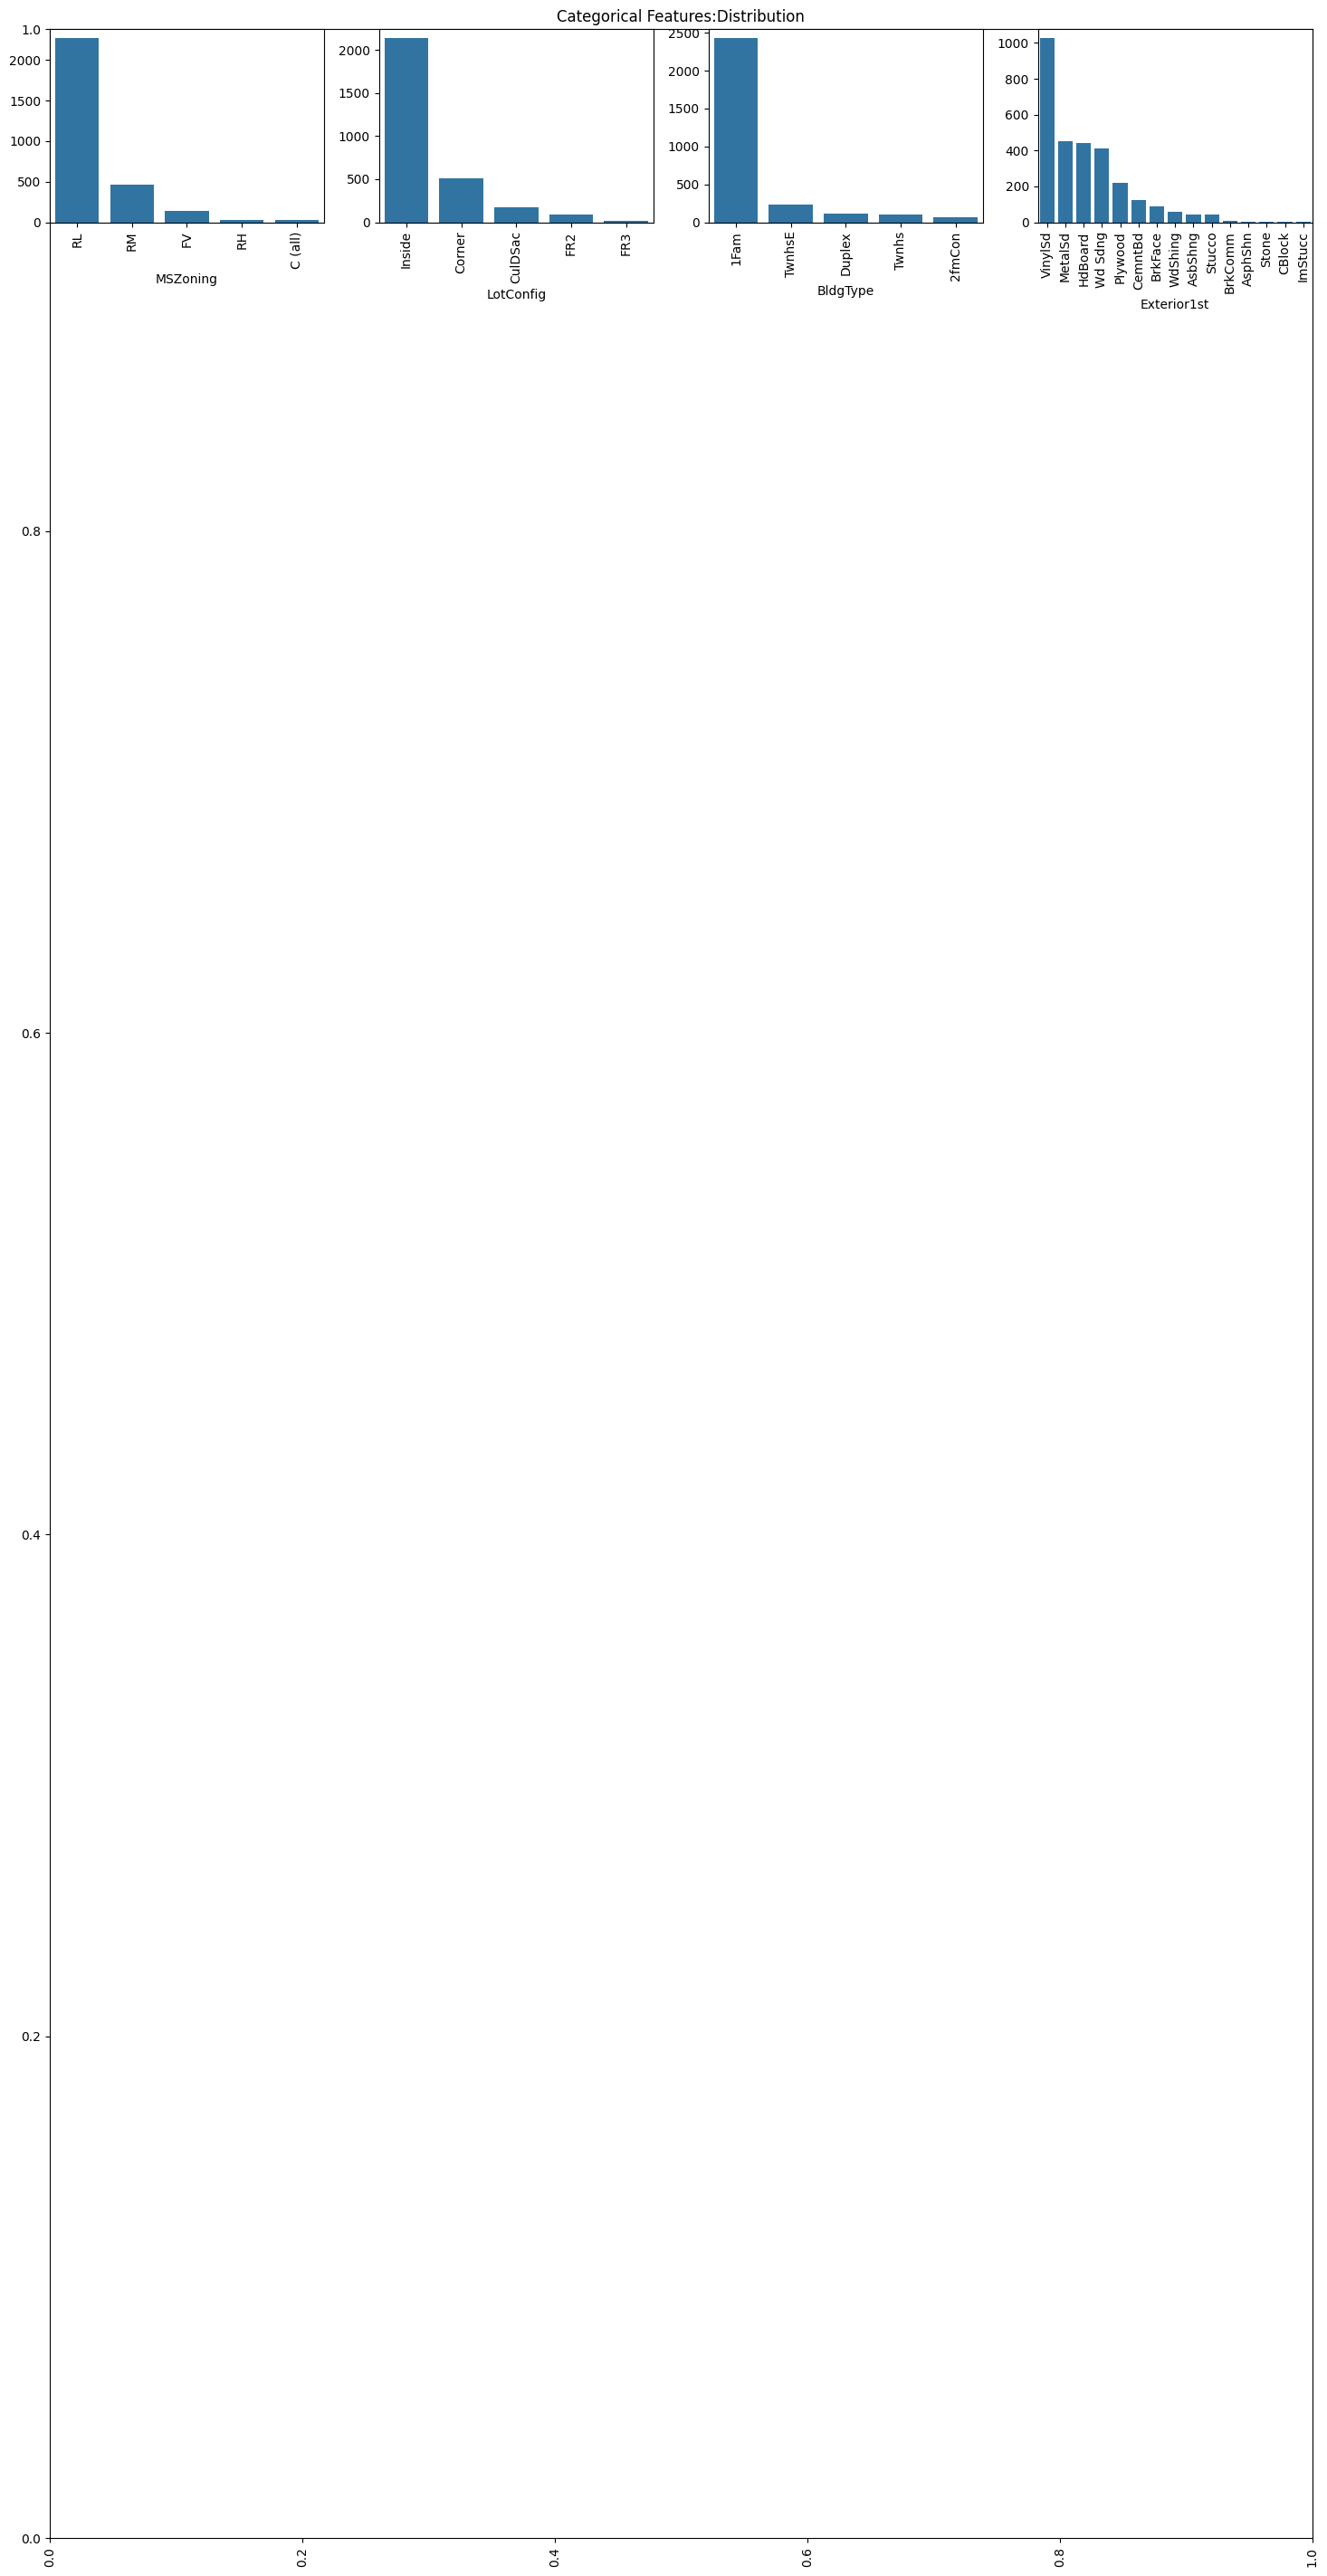

In [8]:
plt.figure(figsize=(18,36))
plt.title("Categorical Features:Distribution")
plt.xticks(rotation=90)
index=1
for col in object_cols:
    y=dataset[col].value_counts()
    plt.subplot(11,4,index)
    plt.xticks(rotation=90)
    sns.barplot(x=y.index,y=y.values)
    index+=1

#### Data Cleaning

In [9]:
dataset.drop(['Id'],axis=1,inplace=True)


In [10]:
new_dataset=dataset.dropna()


In [11]:
new_dataset.isnull().sum()

MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [12]:
# One Hot Encoder
from sklearn.preprocessing import OneHotEncoder
s= (new_dataset.dtypes == 'object')
object_cols = list(s[s].index)
print("Categorical variables:")
print(object_cols)
print("No of Categorical variables:",len(object_cols))

Categorical variables:
['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
No of Categorical variables: 4


In [13]:
from sklearn.preprocessing import OneHotEncoder
OH_encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
OH_cols=pd.DataFrame(OH_encoder.fit_transform(new_dataset[object_cols]))
OH_cols.index=new_dataset.index
OH_cols.columns=OH_encoder.get_feature_names_out()
df_final = new_dataset.drop(object_cols, axis=1)
df_final = pd.concat([df_final,OH_cols], axis=1)
print(df_final)


      MSSubClass  LotArea  OverallCond  YearBuilt  YearRemodAdd  BsmtFinSF2  \
0             60     8450            5       2003          2003         0.0   
1             20     9600            8       1976          1976         0.0   
2             60    11250            5       2001          2002         0.0   
3             70     9550            5       1915          1970         0.0   
4             60    14260            5       2000          2000         0.0   
...          ...      ...          ...        ...           ...         ...   
1455          60     7917            5       1999          2000         0.0   
1456          20    13175            6       1978          1988       163.0   
1457          70     9042            9       1941          2006         0.0   
1458          20     9717            6       1950          1996      1029.0   
1459          20     9937            6       1965          1965       290.0   

      TotalBsmtSF  SalePrice  MSZoning_C (all)  MSZ

#### Splitting the Dataset into Training and Testing

In [14]:
from sklearn.model_selection import train_test_split
X=df_final.drop(['SalePrice'], axis=1)
Y=df_final['SalePrice']
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=0)


#### Model Training and Accuracy

In [15]:
#Linear Regression
from sklearn.linear_model import LinearRegression 
model_LR = LinearRegression()
model_LR.fit(X_train,Y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
Y_pred= model_LR.predict(X_test)
print(Y_pred)

[266378.37472754 128353.69580913 113771.6910079  196886.52332823
  73724.06463269 111636.24994365 261571.75293191 114927.2945413
 369198.15899292 162688.97708698 218839.58434867 227683.12357605
 232616.93982987 172605.78985603 127395.99452403 163825.75252156
 174286.78251757 178295.84943714 190800.53667817 215488.68659035
 163400.55434754 149155.1328668   90300.24392132 171111.93024691
 169097.49969473 157845.50664567 162217.07329937 120967.88808454
 284788.91689661 126332.27675667 188590.55669389 173911.41339781
 220199.33377056 238527.92097004 305654.73369875 183597.5258376
 230174.7870619  127628.79404534 225242.57656346 254751.5147481
 193648.05197936 116575.47403458 225232.82527448 278083.12921229
 269398.3184908  179395.23386335 118201.80647099 120161.19147291
 159164.29497008  63706.91988389 290064.29253295 157135.51710463
 179132.41358478 107236.6788981  283677.87430605 132031.9141819
 101962.27587259 231992.92729972 158221.47943432  82818.86384179
 198745.70425053 132270.98875

In [17]:
from sklearn.metrics import mean_absolute_percentage_error
print(mean_absolute_percentage_error(Y_test,Y_pred))

0.20649186351548185
